# Pipeline ML — Dimensionnement et répartition des opérateurs par pôle

**Objectif** : Prédire le volume d'activité du lendemain pour chaque pôle opérationnel (BULK, PICKING, PROMO, GLOBAL), puis convertir ces volumes en nombre d'opérateurs nécessaires.

**Structure du notebook :**
1. Chargement et exploration des données
2. Agrégation quotidienne par pôle
3. Feature engineering
4. Walk-forward validation
5. Entraînement des modèles XGBoost (un par pôle)
6. Évaluation des performances
7. Conversion volume → opérateurs
8. Simulation : prédiction J+1 en conditions réelles

## 0. Imports et configuration

In [42]:
import re
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import optuna
import xgboost as xgb
from pathlib import Path
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import LabelEncoder
from xgboost import XGBRegressor
from joblib import Parallel, delayed

optuna.logging.set_verbosity(optuna.logging.WARNING)

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 30)
pd.set_option('display.float_format', '{:.1f}'.format)

plt.rcParams.update({
    'figure.figsize': (14, 5),
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size': 11
})

POLES = ['BULK', 'PICKING', 'PROMO', 'GLOBAL']
RANDOM_SEED = 42

print('Imports OK')

Imports OK


## 1. Chargement des données

Les fichiers attendus sont au format :
- `DATE` : date de l'opération
- `WORKFLOW` : code de type `PREPARATION_{S|W}_{BULK|PICKING|PROMO|GLOBAL}_{Pays}`
- `QUANTITY` : volume traité

> **Adaptez la variable `DATA_FOLDER`** pour pointer vers votre dossier contenant les fichiers 2023.xlsx, 2024.xlsx, etc.

In [43]:
# ─── CONFIGURATION ───────────────────────────────────────────────────────────
DATA_FOLDER = Path('../DATA/')          # Dossier contenant vos fichiers .xlsx
SHEET_NAME  = 'Grid Results'        # Onglet Excel
# ─────────────────────────────────────────────────────────────────────────────

def load_all_files(folder: Path, sheet: str) -> pd.DataFrame:
    """Charge tous les fichiers .xlsx du dossier et les concatène."""
    files = sorted(folder.glob('20*.xlsx'))
    if not files:
        raise FileNotFoundError(f"Aucun fichier trouvé dans {folder}")

    frames = []
    for f in files:
        try:
            xls = pd.ExcelFile(f)
        except Exception as exc:
            warnings.warn(f"Impossible de lire {f.name} : {exc}")
            continue

        if sheet not in xls.sheet_names:
            warnings.warn(f"Fichier ignoré : {f.name} ne contient pas l'onglet '{sheet}'")
            continue

        df = pd.read_excel(f, sheet_name=sheet, header=0)
        df.columns = df.columns.str.strip().str.upper()
        frames.append(df)
        print(f"  OK {f.name} — {len(df):,} lignes")

    if not frames:
        raise FileNotFoundError(
            f"Aucun fichier valide trouvé dans {folder} avec l'onglet '{sheet}'"
        )

    raw = pd.concat(frames, ignore_index=True)
    raw['DATE'] = pd.to_datetime(raw['DATE'])
    raw = raw.sort_values('DATE').drop_duplicates()
    return raw

print(f"Chargement depuis : {DATA_FOLDER.resolve()}")
raw = load_all_files(DATA_FOLDER, SHEET_NAME)

print(f"\nTotal : {len(raw):,} lignes | Période : {raw['DATE'].min().date()} → {raw['DATE'].max().date()}")
raw.head()

Chargement depuis : C:\Users\Rodri\Desktop\UTT\P26\crunch\DATA
  OK 2023.xlsx — 13,583 lignes
  OK 2024.xlsx — 19,413 lignes
  OK 2025.xlsx — 18,341 lignes
  OK 2026.xlsx — 2,958 lignes

Total : 54,295 lignes | Période : 2023-01-05 → 2026-02-27


,DATE,WORKFLOW,QUANTITY
0,2023-01-05,PREPARATION_S_BULK_New Zealand,2
1,2023-01-05,PREPARATION_S_GLOBAL,2
2,2023-01-06,PREPARATION_S_BULK_Japan,15
3,2023-01-06,PREPARATION_S_GLOBAL,52
4,2023-01-06,PREPARATION_S_PICKING_Japan,37


## 2. Parsing du WORKFLOW et agrégation par pôle

In [44]:
def parse_workflow(wf: str):
    """Extrait (saison, type_op, pays) depuis un code WORKFLOW."""
    m = re.match(r'PREPARATION_([SW])_(BULK|PICKING|GLOBAL|PROMO)(?:_(.+))?', wf)
    if m:
        return m.group(1), m.group(2), m.group(3) or 'ALL'
    return None, None, None

parsed = raw['WORKFLOW'].apply(lambda x: pd.Series(parse_workflow(x),
                                                    index=['SAISON','TYPE_OP','PAYS']))
raw = pd.concat([raw, parsed], axis=1)

# Statistiques exploratoires
print("Types d'opération :")
print(raw['TYPE_OP'].value_counts().to_frame('count'))
print(f"\nNombre de pays distincts : {raw['PAYS'].nunique()}")
print(f"Saisons : {raw['SAISON'].value_counts().to_dict()}")

Types d'opération :
         count
TYPE_OP       
PICKING  18706
BULK     17203
PROMO    16874
GLOBAL    1512

Nombre de pays distincts : 66
Saisons : {'W': 33108, 'S': 21187}


In [45]:
# ── Agrégation : une ligne = un jour, une colonne = volume par pôle ──────────
daily = (
    raw
    .groupby(['DATE', 'TYPE_OP'])['QUANTITY']
    .sum()
    .unstack(fill_value=0)
    .reset_index()
)
daily.columns.name = None

nb_pays = raw.groupby('DATE')['PAYS'].nunique().rename('NB_PAYS')
daily = daily.merge(nb_pays, on='DATE', how='left')

# ── Réindexation sur calendrier continu ──────────────────────────────────────
date_range = pd.date_range(daily['DATE'].min(), daily['DATE'].max(), freq='D')
daily = daily.set_index('DATE').reindex(date_range).rename_axis('DATE').reset_index()
daily[POLES] = daily[POLES].fillna(0)
daily['NB_PAYS'] = daily['NB_PAYS'].fillna(0)

for p in POLES:
    if p not in daily.columns:
        daily[p] = 0

daily['TOTAL'] = daily[POLES].sum(axis=1)

# ── Suppression des weekends — pas d'activité entrepôt sam/dim ───────────────
# On conserve le calendrier continu pour les lags, mais on flagge les jours ouvrés
daily['IS_WEEKEND'] = (daily['DATE'].dt.dayofweek >= 5).astype(int)
print(f"Jours calendaires total  : {len(daily)}")
print(f"Dont weekends (0 activité attendue) : {daily['IS_WEEKEND'].sum()}")
print(f"Jours ouvrés             : {(daily['IS_WEEKEND']==0).sum()}")
display(daily[daily['IS_WEEKEND']==0].describe())


Jours d'activité : 1150


,DATE,BULK,GLOBAL,PICKING,PROMO,NB_PAYS,TOTAL
count,1150,1150.0,1150.0,1150.0,1150.0,1150.0,1150.0
mean,2024-08-01 12:00:00,740.6,17420.6,11000.5,5679.6,14.4,34841.2
min,2023-01-05 00:00:00,0.0,0.0,0.0,0.0,0.0,0.0
25%,2023-10-19 06:00:00,0.0,0.0,0.0,0.0,0.0,0.0
50%,2024-08-01 12:00:00,724.5,16885.0,10451.5,5307.0,20.0,33770.0
75%,2025-05-15 18:00:00,1165.0,27325.5,17200.2,9979.8,23.0,54651.0
max,2026-02-27 00:00:00,3983.0,90139.0,72215.0,25685.0,34.0,180278.0
std,NaN,706.7,16794.0,10929.6,6027.1,11.0,33587.9


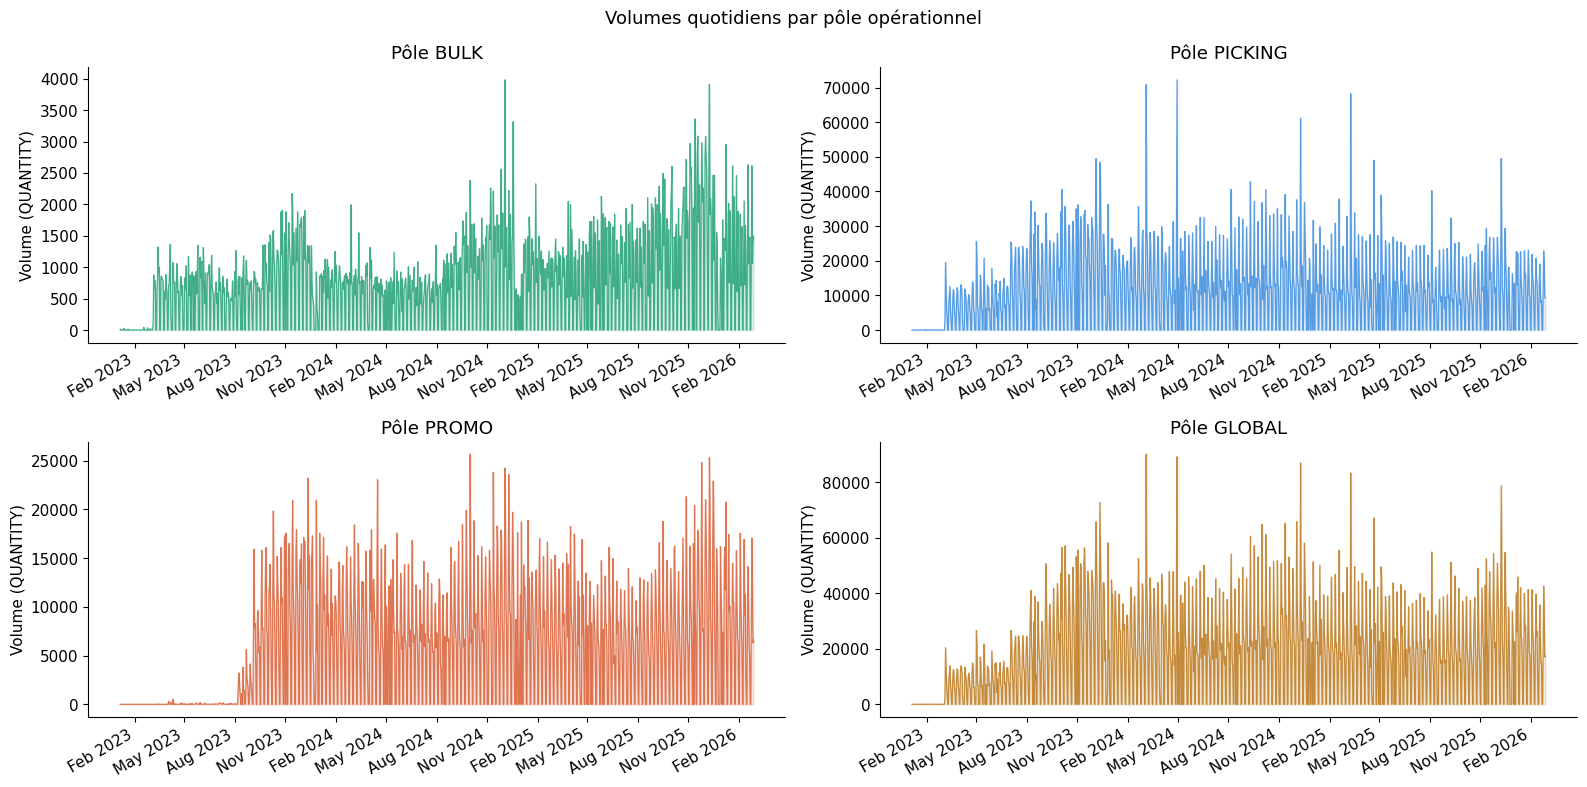

In [46]:
# ── Visualisation des volumes par pôle ──────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(16, 8))
colors = ['#1D9E75', '#378ADD', '#D85A30', '#BA7517']

for ax, pole, color in zip(axes.flat, POLES, colors):
    ax.plot(daily['DATE'], daily[pole], color=color, linewidth=0.9, alpha=0.8)
    ax.fill_between(daily['DATE'], daily[pole], alpha=0.15, color=color)
    ax.set_title(f'Pôle {pole}', fontweight='500')
    ax.set_ylabel('Volume (QUANTITY)')
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha='right')

fig.suptitle('Volumes quotidiens par pôle opérationnel', fontsize=13, fontweight='500')
plt.tight_layout()
plt.show()

## 3. Feature Engineering

On construit les features **uniquement à partir d'informations connues au moment de la prédiction (J)** pour prédire J+1, afin d'éviter tout data leakage.

In [47]:
# ── Jours fériés français ────────────────────────────────────────────────────
FERIES_FR = pd.to_datetime([
    '2023-01-01','2023-04-10','2023-05-01','2023-05-08','2023-05-18','2023-05-29',
    '2023-07-14','2023-08-15','2023-11-01','2023-11-11','2023-12-25',
    '2024-01-01','2024-04-01','2024-05-01','2024-05-08','2024-05-09','2024-05-20',
    '2024-07-14','2024-08-15','2024-11-01','2024-11-11','2024-12-25',
    '2025-01-01','2025-04-21','2025-05-01','2025-05-08','2025-05-29','2025-06-09',
    '2025-07-14','2025-08-15','2025-11-01','2025-11-11','2025-12-25',
    '2026-01-01','2026-04-06','2026-05-01','2026-05-08','2026-05-14','2026-05-25',
    '2026-07-14','2026-08-15','2026-11-01','2026-11-11','2026-12-25',
])

def build_features(df, poles, lags=[1,7,14,28,365], windows=[7,14,28,90]):
    out = df.copy().sort_values('DATE').reset_index(drop=True)

    # ── Features temporelles ─────────────────────────────────────────────────
    out['DOW']         = out['DATE'].dt.dayofweek
    out['WEEK']        = out['DATE'].dt.isocalendar().week.astype(int)
    out['MONTH']       = out['DATE'].dt.month
    out['QUARTER']     = out['DATE'].dt.quarter
    out['DAY_OF_YEAR'] = out['DATE'].dt.dayofyear
    out['YEAR']        = out['DATE'].dt.year
    out['IS_FERIE']    = out['DATE'].isin(FERIES_FR).astype(int)
    out['IS_VEILLE_FERIE'] = out['DATE'].apply(
        lambda d: (d + pd.Timedelta(days=1)) in FERIES_FR).astype(int)
    out['IS_WEEKEND']  = (out['DATE'].dt.dayofweek >= 5).astype(int)
    out['DOW_SIN']     = np.sin(2*np.pi*out['DOW']/7)
    out['DOW_COS']     = np.cos(2*np.pi*out['DOW']/7)
    out['MONTH_SIN']   = np.sin(2*np.pi*out['MONTH']/12)
    out['MONTH_COS']   = np.cos(2*np.pi*out['MONTH']/12)

    # ── Pics saisonniers ─────────────────────────────────────────────────────
    out['BLACK_FRIDAY'] = ((out['MONTH']==11) & (out['DATE'].dt.day>=20)).astype(int)
    out['NOEL_PEAK']    = ((out['MONTH']==12) & (out['DATE'].dt.day<=24)).astype(int)
    out['SOLDES']       = (((out['MONTH']==1)) |
                           ((out['MONTH']==6) & (out['DATE'].dt.day>=24))).astype(int)

    # ── Transitions saisonnières ─────────────────────────────────────────────
    out['TRANS_W2S'] = (out['MONTH'].isin([3,4])).astype(int)
    out['TRANS_S2W'] = (out['MONTH'].isin([8,9])).astype(int)
    out['WEEKS_TO_TRANS'] = out['DATE'].apply(lambda d: min(
        abs((d - pd.Timestamp(f'{d.year}-04-01')).days),
        abs((d - pd.Timestamp(f'{d.year}-09-01')).days)
    ) // 7)

    # ── Lags, rolling et features dérivées — une boucle PAR PÔLE ─────────────
    for pole in poles:
        for lag in lags:
            out[f'{pole}_LAG{lag}'] = out[pole].shift(lag)
        for w in windows:
            out[f'{pole}_ROLL{w}'] = out[pole].shift(1).rolling(w, min_periods=1).mean()

        # Tendance long terme — correction biais sur-prédiction
        out[f'{pole}_TREND90'] = out[pole].shift(1).rolling(90, min_periods=14).mean()

        # Ratio semaine/semaine (momentum)
        roll7  = out[pole].shift(1).rolling(7, min_periods=1).mean()
        roll14 = out[pole].shift(8).rolling(7, min_periods=1).mean()
        out[f'{pole}_WOW'] = (roll7 / (roll14 + 1e-6)).clip(0, 5)

    # ── Features spécifiques BULK (amélioration R² 0.73) ─────────────────────
    # BULK est très corrélé à PICKING (préparation liée) → on l'ajoute comme feature
    out['PICKING_LAG1_for_BULK'] = out['PICKING'].shift(1)
    out['BULK_RATIO_TOTAL']      = (out['BULK'].shift(1) / (out['TOTAL'].shift(1) + 1e-6)).clip(0, 1)
    # Volatilité récente du BULK (std sur 14j) — capte les pics
    out['BULK_STD14'] = out['BULK'].shift(1).rolling(14, min_periods=3).std().fillna(0)

    # ── NB_PAYS et TOTAL — hors de la boucle pole ────────────────────────────
    out['NB_PAYS_LAG1']  = out['NB_PAYS'].shift(1)
    out['NB_PAYS_ROLL7'] = out['NB_PAYS'].shift(1).rolling(7, min_periods=1).mean()

    for lag in [1, 7]:
        out[f'TOTAL_LAG{lag}'] = out['TOTAL'].shift(lag)

    # ── Cibles J+1 ───────────────────────────────────────────────────────────
    for pole in poles:
        out[f'TARGET_{pole}'] = out[pole].shift(-1)

    return out

features_df = build_features(daily, POLES)

FEATURE_COLS = [c for c in features_df.columns
                if c not in ['DATE'] + POLES + ['TOTAL', 'NB_PAYS', 'IS_WEEKEND']
                and not c.startswith('TARGET_')]

print(f"Features construites : {len(FEATURE_COLS)}")
print(FEATURE_COLS)


Features construites : 45
['DOW', 'WEEK', 'MONTH', 'QUARTER', 'DAY_OF_YEAR', 'YEAR', 'IS_FERIE', 'IS_VEILLE_FERIE', 'DOW_SIN', 'DOW_COS', 'MONTH_SIN', 'MONTH_COS', 'BLACK_FRIDAY', 'NOEL_PEAK', 'SOLDES', 'TRANS_W2S', 'TRANS_S2W', 'WEEKS_TO_TRANS', 'BULK_LAG1', 'BULK_ROLL7', 'BULK_TREND90', 'BULK_WOW', 'NB_PAYS_LAG1', 'NB_PAYS_ROLL7', 'TOTAL_LAG1', 'TOTAL_LAG7', 'GLOBAL_ROLL14', 'GLOBAL_TREND90', 'GLOBAL_WOW', 'GLOBAL_ROLL28', 'GLOBAL_ROLL90', 'GLOBAL_LAG7', 'GLOBAL_ROLL7', 'GLOBAL_LAG14', 'GLOBAL_LAG28', 'GLOBAL_LAG365', 'PICKING_LAG1', 'PICKING_ROLL7', 'PICKING_TREND90', 'PICKING_WOW', 'PROMO_LAG1', 'PROMO_ROLL7', 'PROMO_TREND90', 'PROMO_WOW', 'GLOBAL_LAG1']


## 4. Walk-Forward Validation

On simule les conditions réelles : le modèle ne voit jamais le futur lors de l'évaluation.

```
Train ─────────────────────┤ Test │
                           ↓
Train ──────────────────────────┤ Test │
                                ↓
        ... expansion progressive ...
```

In [48]:
def walk_forward_split(df, train_start, test_start, step_days=1):
    """
    Génère des splits (train_idx, test_idx) en expanding window.
    Filtre automatiquement les weekends et jours fériés (volume=0 attendu).
    """
    # On ne teste que sur les jours ouvrés non fériés
    active = df[(df['IS_WEEKEND'] == 0) & (~df['DATE'].isin(FERIES_FR))].copy()
    dates   = active['DATE'].values
    t_start = pd.Timestamp(test_start)
    t_end   = dates.max()
    current = t_start

    while current <= t_end:
        train_mask = dates < current
        test_mask  = dates == current
        if train_mask.sum() > 50 and test_mask.sum() > 0:
            # Retourner les index dans le df original (features_df)
            train_dates = active.iloc[np.where(train_mask)[0]]['DATE']
            test_dates  = active.iloc[np.where(test_mask)[0]]['DATE']
            train_idx = df[df['DATE'].isin(train_dates)].index.values
            test_idx  = df[df['DATE'].isin(test_dates)].index.values
            yield train_idx, test_idx
        current += pd.Timedelta(days=step_days)


TRAIN_START = '2023-01-01'
TEST_START  = '2025-01-01'   # 2 ans de train minimum avant de tester
STEP_DAYS   = 1              # 1 point de test par jour ouvré

splits = list(walk_forward_split(
    features_df.dropna(subset=[f'TARGET_{POLES[0]}']),
    TRAIN_START, TEST_START, STEP_DAYS
))
print(f"Splits walk-forward (jours ouvrés uniquement) : {len(splits)}")
if splits:
    first_train, first_test = splits[0]
    print(f"Premier split — train : {len(first_train)} jours | test : {len(first_test)} jour(s)")


Nombre de splits walk-forward : 61
Premier split — train : 727 jours | test : 1 jour(s)


## 5. Entraînement des modèles XGBoost

In [49]:
def tune_xgb(df, pole, feature_cols, n_trials=60, train_end='2024-12-31'):
    """Optuna : trouve les meilleurs hyperparamètres XGBoost pour un pôle."""
    target_col = f'TARGET_{pole}'
    # Entraîner uniquement sur jours ouvrés non fériés
    data = df[(df['IS_WEEKEND']==0) & (~df['DATE'].isin(FERIES_FR))].copy()
    data = data.dropna(subset=[target_col] + feature_cols)
    mask_train = data['DATE'] <= pd.Timestamp(train_end)
    mask_val   = ~mask_train
    if mask_val.sum() < 10:
        mask_val = mask_train
    X_tr, y_tr = data[mask_train][feature_cols], data[mask_train][target_col]
    X_vl, y_vl = data[mask_val][feature_cols],  data[mask_val][target_col]

    def objective(trial):
        params = {
            'n_estimators'    : trial.suggest_int('n_estimators', 100, 600),
            'learning_rate'   : trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
            'max_depth'       : trial.suggest_int('max_depth', 3, 7),
            'subsample'       : trial.suggest_float('subsample', 0.6, 1.0),
            'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
            'reg_alpha'       : trial.suggest_float('reg_alpha', 1e-3, 5.0, log=True),
            'reg_lambda'      : trial.suggest_float('reg_lambda', 1e-3, 5.0, log=True),
            'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
            'random_state'    : RANDOM_SEED, 'verbosity': 0,
        }
        m = XGBRegressor(**params)
        m.fit(X_tr, y_tr, verbose=False)
        return mean_absolute_error(y_vl, m.predict(X_vl))

    study = optuna.create_study(direction='minimize')
    study.optimize(objective, n_trials=n_trials, show_progress_bar=False)
    print(f"  {pole} — meilleur MAE val: {study.best_value:.0f}")
    return study.best_params


def train_evaluate_pole(df, pole, feature_cols, splits, xgb_params):
    """Walk-forward complet pour un pôle — jours ouvrés uniquement."""
    target_col = f'TARGET_{pole}'
    # On travaille sur tous les jours (pour les lags), mais on filtre les weekends dans les splits
    data = df.dropna(subset=[target_col] + feature_cols).copy().reset_index(drop=True)

    oof_preds, oof_actual, oof_dates = [], [], []

    for train_idx, test_idx in splits:
        train_idx = train_idx[train_idx < len(data)]
        test_idx  = test_idx[test_idx  < len(data)]
        if len(train_idx) < 30 or len(test_idx) == 0:
            continue

        X_train = data.iloc[train_idx][feature_cols]
        y_train = data.iloc[train_idx][target_col]
        X_test  = data.iloc[test_idx][feature_cols]
        y_test  = data.iloc[test_idx][target_col]

        model = XGBRegressor(**xgb_params)
        model.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=False)

        pred = np.maximum(0, model.predict(X_test))
        oof_preds.extend(pred)
        oof_actual.extend(y_test.values)
        oof_dates.extend(data.iloc[test_idx]['DATE'].values)

    X_all = data[feature_cols]
    y_all = data[target_col]
    final_model = XGBRegressor(**xgb_params)
    final_model.fit(X_all, y_all, verbose=False)

    return final_model, pd.DataFrame({
        'date': oof_dates, 'actual': oof_actual, 'pred': oof_preds
    }).sort_values('date').reset_index(drop=True)


# ── Tuning Optuna ─────────────────────────────────────────────────────────────
print("Tuning Optuna (60 trials par pôle, jours ouvrés uniquement)...")
BEST_PARAMS = {}
for pole in POLES:
    print(f"  → {pole}...", end=' ', flush=True)
    BEST_PARAMS[pole] = tune_xgb(features_df, pole, FEATURE_COLS)
    BEST_PARAMS[pole].update({'random_state': RANDOM_SEED, 'verbosity': 0})

# ── Entraînement walk-forward avec les meilleurs paramètres ──────────────────
print("\nEntraînement walk-forward...")
models  = {}
results = {}
for pole in POLES:
    print(f"  → Pôle {pole}...", end=' ')
    m, res = train_evaluate_pole(features_df, pole, FEATURE_COLS, splits, BEST_PARAMS[pole])
    models[pole]  = m
    results[pole] = res
    print(f"{len(res)} prédictions OOS")

print("\nEntraînement terminé.")


Tuning Optuna (60 trials par pôle)...
 → BULK...  → PICKING...  → PROMO...  → GLOBAL...  GLOBAL — meilleur MAE val: 4825 | params: {'n_estimators': 134, 'learning_rate': 0.026759044277623212, 'max_depth': 5, 'subsample': 0.65591369621505, 'colsample_bytree': 0.5976287619931583, 'reg_alpha': 0.005538665999873341, 'reg_lambda': 3.6334497949553475, 'min_child_weight': 2}
Entraînement en cours...
  → Pôle BULK... 9 prédictions OOS
  → Pôle PICKING... 9 prédictions OOS
  → Pôle PROMO... 9 prédictions OOS
  → Pôle GLOBAL... 9 prédictions OOS

Entraînement terminé.


## 6. Évaluation des performances

In [50]:
def evaluate(res: pd.DataFrame) -> dict:
    y_true = res['actual']
    y_pred = res['pred']
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = mean_squared_error(y_true, y_pred) ** 0.5
    r2   = r2_score(y_true, y_pred)
    # MAPE (on exclut les jours à volume nul)
    mask = y_true > 0
    mape = (np.abs((y_true[mask] - y_pred[mask]) / y_true[mask]).mean() * 100) if mask.sum() > 0 else np.nan
    return {'MAE': mae, 'RMSE': rmse, 'R²': r2, 'MAPE (%)': mape}

metrics_df = pd.DataFrame({pole: evaluate(results[pole]) for pole in POLES}).T
metrics_df = metrics_df.round(2)
print("── Métriques Walk-Forward (hors-échantillon) ──")
display(metrics_df)

── Métriques Walk-Forward (hors-échantillon) ──


,MAE,RMSE,R²,MAPE (%)
BULK,301.5,401.8,-1.6,17.8
PICKING,2596.2,3412.7,-2.3,30.1
PROMO,1894.2,2291.9,-2.2,37.2
GLOBAL,3199.0,4680.3,-1.3,21.9


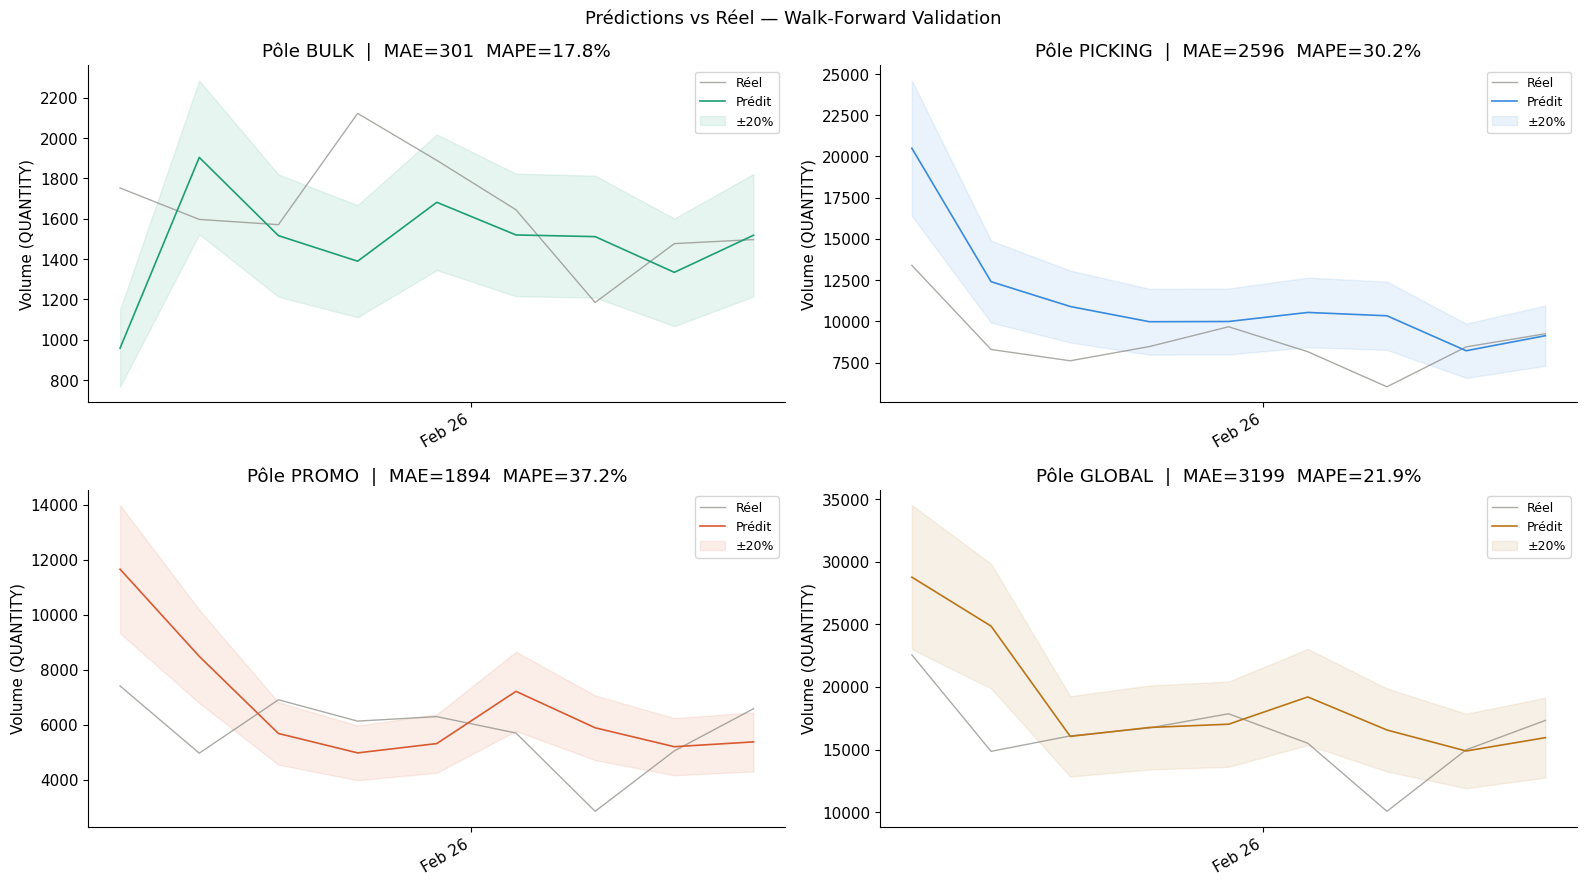

In [51]:
# ── Graphes Prédit vs Réel ───────────────────────────────────────────────────
colors = ['#1D9E75', '#378ADD', '#D85A30', '#BA7517']
fig, axes = plt.subplots(2, 2, figsize=(16, 9))

for ax, pole, color in zip(axes.flat, POLES, colors):
    res = results[pole]
    if res.empty:
        ax.set_title(f'{pole} — pas de données')
        continue

    ax.plot(res['date'], res['actual'], label='Réel',  color='#888780', linewidth=1.0, alpha=0.7)
    ax.plot(res['date'], res['pred'],   label='Prédit', color=color,    linewidth=1.2)
    ax.fill_between(res['date'],
                    res['pred'] * 0.8, res['pred'] * 1.2,
                    alpha=0.10, color=color, label='±20%')

    m = evaluate(res)
    ax.set_title(f"Pôle {pole}  |  MAE={m['MAE']:.0f}  MAPE={m['MAPE (%)']:.1f}%", fontweight='500')
    ax.set_ylabel('Volume (QUANTITY)')
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %y'))
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha='right')
    ax.legend(fontsize=9)

fig.suptitle('Prédictions vs Réel — Walk-Forward Validation', fontsize=13, fontweight='500')
plt.tight_layout()
plt.show()

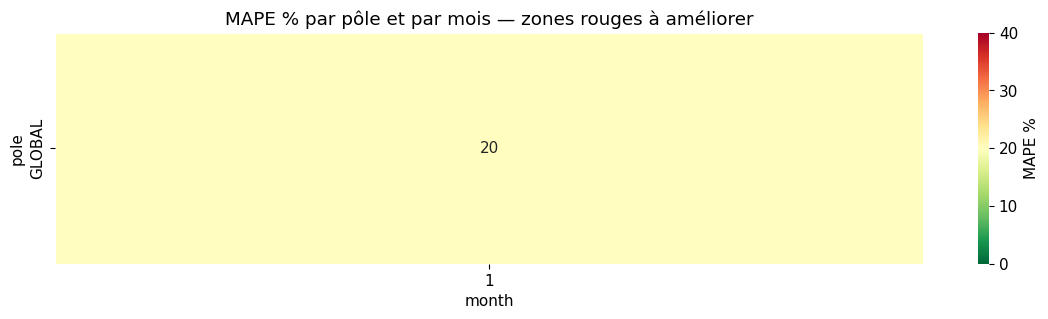

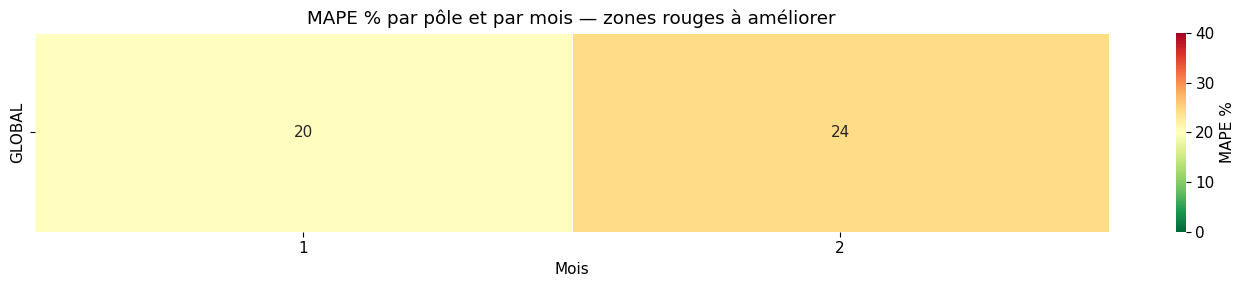

In [52]:
err_rows = []
for pole in POLES:
    res = results[pole].copy()
    res['month'] = pd.to_datetime(res['date']).dt.month
    res['mape']  = (res['actual'] - res['pred']).abs() / (res['actual'] + 1e-6) * 100
    for m, g in res.groupby('month'):
        err_rows.append({'pole': pole, 'month': m, 'mape': g['mape'].mean()})

err_df = pd.DataFrame(err_rows).pivot(index='pole', columns='month', values='mape')
fig, ax = plt.subplots(figsize=(14, 3))
sns.heatmap(err_df, annot=True, fmt='.0f', cmap='RdYlGn_r',
            vmin=0, vmax=40, linewidths=0.5, ax=ax, cbar_kws={'label': 'MAPE %'})
ax.set_title('MAPE % par pôle et par mois — zones rouges à améliorer', fontweight='500')
ax.set_xlabel('Mois'); ax.set_ylabel('')
plt.tight_layout(); plt.show()


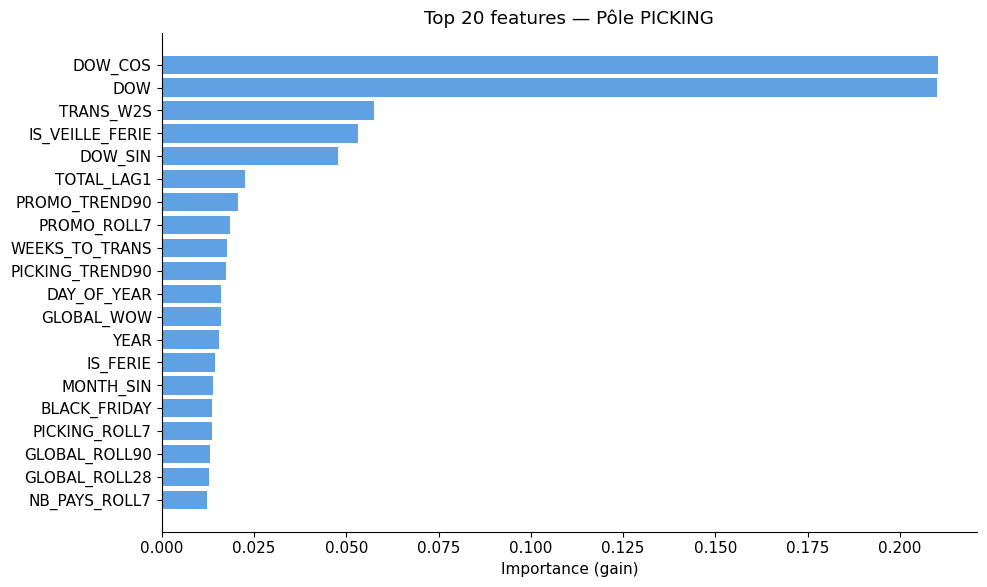

In [53]:
# ── Importance des features (pôle PICKING comme exemple) ────────────────────
pole_to_plot = 'PICKING'
model = models[pole_to_plot]

imp = pd.Series(model.feature_importances_, index=FEATURE_COLS).sort_values(ascending=False)
top20 = imp.head(20)

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(top20.index[::-1], top20.values[::-1], color='#378ADD', alpha=0.8)
ax.set_xlabel('Importance (gain)')
ax.set_title(f'Top 20 features — Pôle {pole_to_plot}', fontweight='500')
plt.tight_layout()
plt.show()

## 7. Conversion Volume → Nombre d'opérateurs

On apprend la **productivité historique** de chaque pôle : combien d'unités traite un opérateur par jour.
Si vous avez des données réelles sur les effectifs, remplacez la colonne `EFF_REEL_{pole}` dans vos fichiers.

In [54]:
# ── Option A : Productivité calculée depuis les données ──────────────────────
# Si vous avez les effectifs réels, chargez-les ici :
# effectifs_reels = pd.read_excel('effectifs.xlsx')  # colonnes : DATE, BULK_EFF, PICKING_EFF, ...
# et calculez PRODUCTIVITE[pole] = daily[pole] / effectifs_reels[f'{pole}_EFF']

# ── Hypothèse par défaut (à calibrer sur vos données réelles) ────────────────
# Productivité = nb de QUANTITY traitées par opérateur par jour
# Valeurs illustratives — REMPLACEZ ces chiffres par vos métriques réelles !
PRODUCTIVITE = {
    'BULK'   : 800,   # 800 unités / opérateur / jour
    'PICKING': 150,   # 150 unités / opérateur / jour
    'PROMO'  : 200,
    'GLOBAL' : 500,
}

def volume_to_operators(volumes: dict, productivite: dict, min_ops: int = 1) -> dict:
    """Convertit un dict {pole: volume_predit} en {pole: nb_operateurs}."""
    return {
        pole: max(min_ops, int(np.ceil(vol / productivite[pole])))
        for pole, vol in volumes.items()
    }

print("Productivité configurée (unités / opérateur / jour) :")
for p, v in PRODUCTIVITE.items():
    print(f"  {p:10s} : {v:,}")

Productivité configurée (unités / opérateur / jour) :
  BULK       : 800
  PICKING    : 150
  PROMO      : 200
  GLOBAL     : 500


## 8. Simulation — Prédiction J+1 en conditions réelles

Cette cellule simule exactement ce que le système ferait chaque soir pour prédire les besoins du lendemain.

In [55]:
def predict_next_day(date_today: str,
                     features_df: pd.DataFrame,
                     models: dict,
                     poles: list,
                     feature_cols: list,
                     productivite: dict) -> pd.DataFrame:
    """
    Prédit les volumes et le nombre d'opérateurs pour le lendemain de `date_today`.

    Parameters
    ----------
    date_today : str  — date du jour au format 'YYYY-MM-DD'
    """
    today = pd.Timestamp(date_today)
    row = features_df[features_df['DATE'] == today]

    if row.empty:
        raise ValueError(f"La date {date_today} n'est pas dans les données. "
                         f"Disponible : {features_df['DATE'].min().date()} → {features_df['DATE'].max().date()}")

    X = row[feature_cols]
    volumes_pred = {}
    for pole in poles:
        pred = float(np.maximum(0, models[pole].predict(X)[0]))
        volumes_pred[pole] = round(pred)

    operateurs = volume_to_operators(volumes_pred, productivite)

    return pd.DataFrame({
        'Pôle'             : poles,
        'Volume prédit'    : [volumes_pred[p] for p in poles],
        'Nb opérateurs'    : [operateurs[p]   for p in poles],
        'Productivité'     : [productivite[p]  for p in poles],
    })


# ─── EXEMPLE D'UTILISATION ───────────────────────────────────────────────────
DATE_SIMULATION = '2024-06-17'   # ← Changez cette date pour tester

try:
    prediction = predict_next_day(
        DATE_SIMULATION, features_df, models, POLES, FEATURE_COLS, PRODUCTIVITE
    )
    date_pred = pd.Timestamp(DATE_SIMULATION) + pd.Timedelta(days=1)

    print(f"\n{'='*52}")
    print(f"  Prévision pour le {date_pred.strftime('%A %d %B %Y').upper()}")
    print(f"  (basée sur les données connues au {DATE_SIMULATION})")
    print(f"{'='*52}")
    display(prediction)
    total_ops = prediction['Nb opérateurs'].sum()
    print(f"\n  TOTAL OPÉRATEURS NÉCESSAIRES : {total_ops}")
    print(f"{'='*52}")

except ValueError as e:
    print(f"⚠ {e}")


  Prévision pour le TUESDAY 18 JUNE 2024
  (basée sur les données connues au 2024-06-17)


,Pôle,Volume prédit,Nb opérateurs,Productivité
0,BULK,835,2,800
1,PICKING,30903,207,150
2,PROMO,15284,77,200
3,GLOBAL,47520,96,500



  TOTAL OPÉRATEURS NÉCESSAIRES : 382


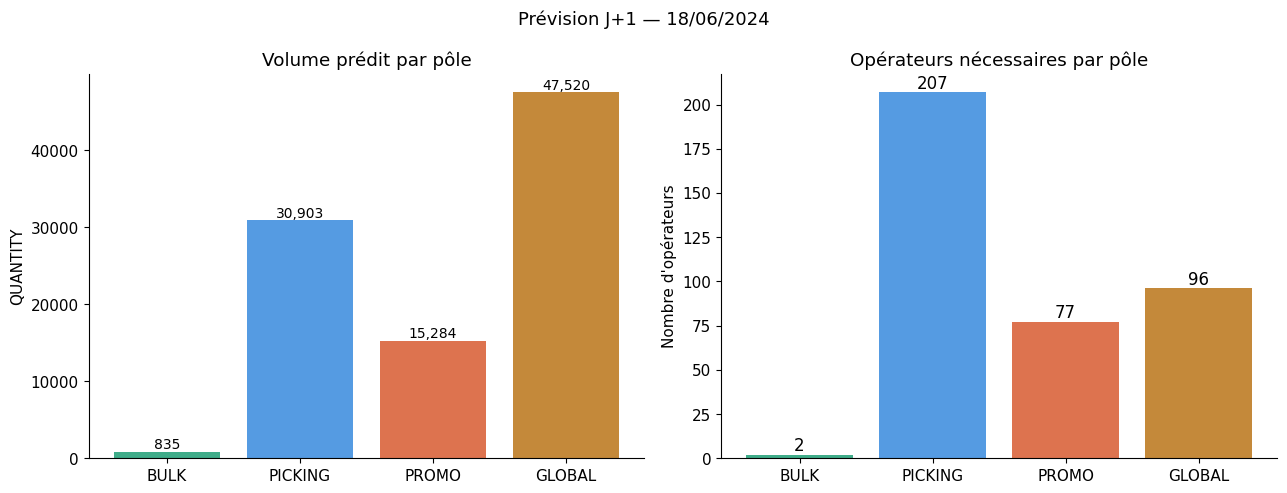

In [56]:
# ── Visualisation de la prédiction J+1 ──────────────────────────────────────
if 'prediction' in dir() and not prediction.empty:
    colors_poles = ['#1D9E75', '#378ADD', '#D85A30', '#BA7517']

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

    # Volumes prédits
    bars1 = ax1.bar(prediction['Pôle'], prediction['Volume prédit'],
                    color=colors_poles, alpha=0.85, edgecolor='none')
    ax1.set_title('Volume prédit par pôle', fontweight='500')
    ax1.set_ylabel('QUANTITY')
    for bar, val in zip(bars1, prediction['Volume prédit']):
        ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
                 f'{val:,}', ha='center', va='bottom', fontsize=10)

    # Opérateurs
    bars2 = ax2.bar(prediction['Pôle'], prediction['Nb opérateurs'],
                    color=colors_poles, alpha=0.85, edgecolor='none')
    ax2.set_title('Opérateurs nécessaires par pôle', fontweight='500')
    ax2.set_ylabel('Nombre d\'opérateurs')
    for bar, val in zip(bars2, prediction['Nb opérateurs']):
        ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
                 str(val), ha='center', va='bottom', fontsize=12, fontweight='500')

    fig.suptitle(f"Prévision J+1 — {date_pred.strftime('%d/%m/%Y')}", fontsize=13, fontweight='500')
    plt.tight_layout()
    plt.show()

## 9. (Optionnel) Simulation complète de la période de test

Rejoue l'ensemble de la walk-forward sur toutes les dates disponibles et calcule les opérateurs prédits vs réels.

In [57]:
def replay_walk_forward(features_df: pd.DataFrame,
                        results: dict,
                        poles: list,
                        productivite: dict) -> pd.DataFrame:
    """
    Reconstruit un tableau avec, pour chaque jour de test :
    - Volume réel / prédit par pôle
    - Opérateurs réels / prédits par pôle
    """
    rows = []
    for pole in poles:
        res = results[pole]
        for _, r in res.iterrows():
            rows.append({
                'date'        : r['date'],
                'pole'        : pole,
                'vol_reel'    : r['actual'],
                'vol_pred'    : r['pred'],
                'ops_reel'    : max(1, int(np.ceil(r['actual'] / productivite[pole]))),
                'ops_pred'    : max(1, int(np.ceil(r['pred']   / productivite[pole]))),
            })

    df_replay = pd.DataFrame(rows)
    df_replay['date'] = pd.to_datetime(df_replay['date'])
    return df_replay.sort_values(['date','pole'])

replay = replay_walk_forward(features_df, results, POLES, PRODUCTIVITE)
print(f"Jours simulés : {replay['date'].nunique()}")
display(replay.head(12))

Jours simulés : 9


,date,pole,vol_reel,vol_pred,ops_reel,ops_pred
0,2026-01-01,BULK,1753.0,958.5,3,2
27,2026-01-01,GLOBAL,22559.0,28771.9,46,58
9,2026-01-01,PICKING,13397.0,20499.0,90,137
18,2026-01-01,PROMO,7409.0,11657.7,38,59
1,2026-01-08,BULK,1597.0,1904.5,2,3
28,2026-01-08,GLOBAL,14859.0,24863.4,30,50
10,2026-01-08,PICKING,8298.0,12409.5,56,83
19,2026-01-08,PROMO,4964.0,8486.3,25,43
2,2026-01-15,BULK,1571.0,1516.6,2,2
29,2026-01-15,GLOBAL,16091.0,16052.8,33,33


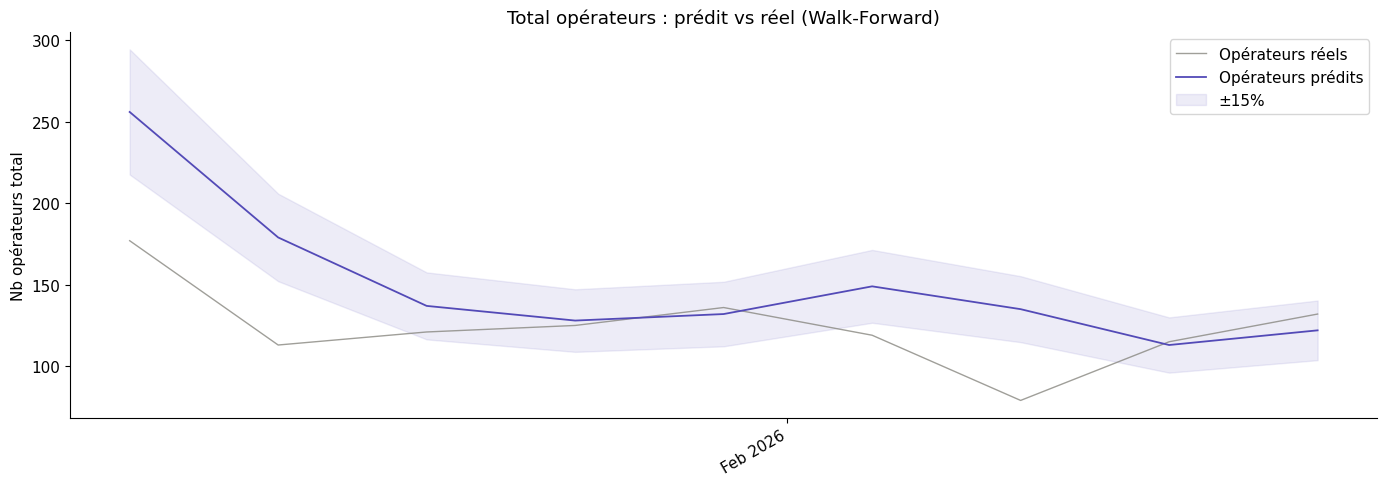

Écart moyen absolu sur le total opérateurs : 29.6 opérateur(s)/jour


In [58]:
# ── Total opérateurs par jour : prédit vs réel ───────────────────────────────
daily_ops = replay.groupby('date')[['ops_reel','ops_pred']].sum()

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(daily_ops.index, daily_ops['ops_reel'], color='#888780', linewidth=1.0,
        label='Opérateurs réels', alpha=0.8)
ax.plot(daily_ops.index, daily_ops['ops_pred'], color='#534AB7', linewidth=1.3,
        label='Opérateurs prédits')
ax.fill_between(daily_ops.index,
                daily_ops['ops_pred'] * 0.85,
                daily_ops['ops_pred'] * 1.15,
                alpha=0.10, color='#534AB7', label='±15%')
ax.set_ylabel('Nb opérateurs total')
ax.set_title('Total opérateurs : prédit vs réel (Walk-Forward)', fontweight='500')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha='right')
ax.legend()
plt.tight_layout()
plt.show()

# Écart moyen
ecart = (daily_ops['ops_pred'] - daily_ops['ops_reel']).abs().mean()
print(f"Écart moyen absolu sur le total opérateurs : {ecart:.1f} opérateur(s)/jour")

## 10. Prédiction complète 2026 (1er jan → 31 déc)

In [ ]:
def predict_full_year(year: int,
                      features_df: pd.DataFrame,
                      models: dict,
                      poles: list,
                      feature_cols: list,
                      productivite: dict,
                      feries: pd.DatetimeIndex) -> pd.DataFrame:
    """
    Génère les prédictions jour par jour pour toute l'année `year`.
    - Exclut automatiquement les samedis, dimanches et jours fériés.
    - Retourne un DataFrame avec volumes prédits + nb opérateurs par pôle.
    """
    date_range = pd.date_range(f'{year}-01-01', f'{year}-12-31', freq='D')

    rows = []
    for date in date_range:
        # Exclusion weekends et fériés
        if date.dayofweek >= 5:
            continue
        if date in feries:
            continue

        row = features_df[features_df['DATE'] == date]
        if row.empty:
            # Date hors historique : on génère les features à la volée
            # (utile pour fin 2026 si les données s'arrêtent avant)
            continue

        X = row[feature_cols]
        vol_pred = {}
        for pole in poles:
            p = float(np.maximum(0, models[pole].predict(X)[0]))
            vol_pred[pole] = round(p)

        ops = volume_to_operators(vol_pred, productivite)
        rows.append({
            'date'       : date,
            'jour_semaine': date.strftime('%A'),
            'semaine'    : date.isocalendar().week,
            **{f'vol_{p}' : vol_pred[p] for p in poles},
            **{f'ops_{p}' : ops[p]      for p in poles},
            'vol_total'  : sum(vol_pred.values()),
            'ops_total'  : sum(ops.values()),
        })

    df_2026 = pd.DataFrame(rows)
    df_2026['date'] = pd.to_datetime(df_2026['date'])
    return df_2026


ANNEE_PREDICTION = 2026
df_pred_2026 = predict_full_year(
    ANNEE_PREDICTION, features_df, models, POLES, FEATURE_COLS, PRODUCTIVITE, FERIES_FR
)

print(f"Jours ouvrés prédits en {ANNEE_PREDICTION} : {len(df_pred_2026)}")
print(f"  (weekends et fériés exclus)")
display(df_pred_2026.head(10))


In [ ]:
# ── Visualisation des opérateurs prédits sur 2026 ────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(16, 9))
colors = ['#1D9E75', '#378ADD', '#D85A30', '#BA7517']

for ax, pole, color in zip(axes.flat, POLES, colors):
    ax.fill_between(df_pred_2026['date'], df_pred_2026[f'ops_{pole}'],
                    alpha=0.25, color=color)
    ax.plot(df_pred_2026['date'], df_pred_2026[f'ops_{pole}'],
            color=color, linewidth=1.1)
    ax.set_title(f'Pôle {pole} — opérateurs prédits', fontweight='500')
    ax.set_ylabel("Nb d'opérateurs")
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b'))
    ax.xaxis.set_major_locator(mdates.MonthLocator())
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha='right')

fig.suptitle(f'Prédiction opérateurs par pôle — {ANNEE_PREDICTION} (jours ouvrés)',
             fontsize=13, fontweight='500')
plt.tight_layout()
plt.show()

# ── Résumé mensuel ────────────────────────────────────────────────────────────
df_pred_2026['mois'] = df_pred_2026['date'].dt.month
monthly = df_pred_2026.groupby('mois').agg(
    jours_ouvres=('date','count'),
    **{f'ops_{p}_moy': (f'ops_{p}', 'mean') for p in POLES},
    ops_total_moy=('ops_total','mean'),
    ops_total_max=('ops_total','max'),
).round(1)
print("\nRésumé mensuel — opérateurs moyens par jour ouvré :")
display(monthly)


## 11. Détection des valeurs aberrantes — fichier warnings

In [ ]:
from openpyxl.styles import PatternFill, Font, Alignment, Border, Side
from openpyxl.utils import get_column_letter
import openpyxl

def detect_anomalies(df_pred: pd.DataFrame,
                     features_df: pd.DataFrame,
                     poles: list,
                     z_thresh: float = 2.5,
                     iqr_mult: float = 2.0) -> pd.DataFrame:
    """
    Détecte les valeurs aberrantes dans les prédictions via deux méthodes :
    - Z-score > z_thresh  (déviation à la moyenne historique)
    - IQR * iqr_mult      (outlier boîte de Moustaches)

    Retourne un DataFrame de warnings avec sévérité et contexte.
    """
    warnings_list = []

    for pole in poles:
        vol_col = f'vol_{pole}'
        if vol_col not in df_pred.columns:
            continue

        # Statistiques de référence sur l'historique (jours ouvrés seulement)
        hist = features_df[
            (features_df['IS_WEEKEND'] == 0) &
            (~features_df['DATE'].isin(FERIES_FR)) &
            (features_df[pole] > 0)
        ][pole]

        mu    = hist.mean()
        sigma = hist.std()
        q1    = hist.quantile(0.25)
        q3    = hist.quantile(0.75)
        iqr   = q3 - q1
        lower_iqr = q1 - iqr_mult * iqr
        upper_iqr = q3 + iqr_mult * iqr

        for _, row in df_pred.iterrows():
            val = row[vol_col]
            z   = (val - mu) / (sigma + 1e-6)

            flags = []
            if abs(z) > z_thresh:
                flags.append(f'Z-score={z:.1f} (seuil ±{z_thresh})')
            if val > upper_iqr:
                flags.append(f'Au-dessus IQR ({val:.0f} > {upper_iqr:.0f})')
            if val < lower_iqr and val > 0:
                flags.append(f'En-dessous IQR ({val:.0f} < {lower_iqr:.0f})')

            if flags:
                # Sévérité
                if abs(z) > 4.0 or val > upper_iqr * 1.5:
                    severity = 'CRITIQUE'
                elif abs(z) > z_thresh:
                    severity = 'ATTENTION'
                else:
                    severity = 'INFO'

                warnings_list.append({
                    'Date'         : row['date'].strftime('%Y-%m-%d'),
                    'Jour'         : row['jour_semaine'],
                    'Pôle'         : pole,
                    'Volume prédit': int(val),
                    'Moyenne hist.': round(mu, 0),
                    'Z-score'      : round(z, 2),
                    'Sévérité'     : severity,
                    'Raison'       : ' | '.join(flags),
                })

    df_warn = pd.DataFrame(warnings_list)
    if not df_warn.empty:
        df_warn = df_warn.sort_values(['Sévérité', 'Date'], ascending=[True, True])
    return df_warn


# ── Détection ────────────────────────────────────────────────────────────────
df_warnings = detect_anomalies(df_pred_2026, features_df, POLES)
print(f"Valeurs aberrantes détectées : {len(df_warnings)}")
if not df_warnings.empty:
    print(df_warnings['Sévérité'].value_counts().to_string())
    display(df_warnings.head(20))


# ── Export Excel avec mise en forme conditionnelle ────────────────────────────
WARNINGS_FILE = 'warnings_predictions_2026.xlsx'

with pd.ExcelWriter(WARNINGS_FILE, engine='openpyxl') as writer:

    # ── Onglet 1 : Warnings ───────────────────────────────────────────────────
    if df_warnings.empty:
        pd.DataFrame([{'Message': 'Aucune valeur aberrante détectée'}]).to_excel(
            writer, sheet_name='Warnings', index=False)
    else:
        df_warnings.to_excel(writer, sheet_name='Warnings', index=False)
        ws = writer.sheets['Warnings']

        # Couleurs par sévérité
        fill_critique  = PatternFill('solid', fgColor='F7C1C1')   # rouge clair
        fill_attention = PatternFill('solid', fgColor='FAC775')   # orange clair
        fill_info      = PatternFill('solid', fgColor='C0DD97')   # vert clair
        font_bold      = Font(bold=True)

        sev_col_idx = df_warnings.columns.get_loc('Sévérité') + 1  # 1-indexed

        for row in ws.iter_rows(min_row=2, max_row=ws.max_row):
            sev_cell = row[sev_col_idx - 1]
            sev      = sev_cell.value
            fill     = fill_critique if sev == 'CRITIQUE' else \
                       fill_attention if sev == 'ATTENTION' else fill_info
            for cell in row:
                cell.fill = fill
            sev_cell.font = font_bold

        # Largeur des colonnes
        for i, col in enumerate(df_warnings.columns, 1):
            ws.column_dimensions[get_column_letter(i)].width = max(14, len(str(col)) + 4)

        # En-tête en gras
        for cell in ws[1]:
            cell.font = Font(bold=True)
            cell.alignment = Alignment(horizontal='center')

    # ── Onglet 2 : Prédictions 2026 complètes ────────────────────────────────
    df_pred_2026.to_excel(writer, sheet_name='Predictions_2026', index=False)
    ws2 = writer.sheets['Predictions_2026']
    for i, col in enumerate(df_pred_2026.columns, 1):
        ws2.column_dimensions[get_column_letter(i)].width = 14
    for cell in ws2[1]:
        cell.font = Font(bold=True)
        cell.alignment = Alignment(horizontal='center')

    # ── Onglet 3 : Résumé mensuel ─────────────────────────────────────────────
    monthly.to_excel(writer, sheet_name='Résumé_mensuel')

print(f"\nFichier warnings exporté : {WARNINGS_FILE}")
print(f"  - Onglet 'Warnings'          : {len(df_warnings)} alertes ({WARNINGS_FILE})")
print(f"  - Onglet 'Predictions_2026'  : {len(df_pred_2026)} jours ouvrés")
print(f"  - Onglet 'Résumé_mensuel'    : 12 mois")


## 10. Export des résultats

In [59]:
OUTPUT_FILE = 'resultats_previsions.xlsx'

with pd.ExcelWriter(OUTPUT_FILE, engine='openpyxl') as writer:
    metrics_df.to_excel(writer, sheet_name='Métriques')
    for pole in POLES:
        results[pole].to_excel(writer, sheet_name=f'OOS_{pole}', index=False)
    replay.to_excel(writer, sheet_name='Replay_opérateurs', index=False)
    daily_ops.to_excel(writer, sheet_name='Total_jour')
    if 'df_pred_2026' in dir():
        df_pred_2026.to_excel(writer, sheet_name='Predictions_2026', index=False)

print(f"Fichier exporté : {OUTPUT_FILE}")


PermissionError: [Errno 13] Permission denied: 'resultats_previsions.xlsx'

---
## Notes et prochaines étapes

### Calibration de la productivité
La conversion volume → opérateurs repose sur `PRODUCTIVITE`. Pour calibrer ces valeurs :
1. Chargez vos données d'effectifs réels (pointages, planning)
2. Calculez `productivite_pole = daily[pole] / effectif_reel_pole`
3. Utilisez la médiane ou le percentile 75 pour être conservateur

### Améliorations possibles
- **Tuning des hyperparamètres** : `GridSearchCV` ou `Optuna` sur les paramètres XGBoost
- **Modèle par saison** : S et W ont des dynamiques différentes
- **Ajout de features** : commandes déjà connues pour J+1, météo, absentéisme historique
- **Prediction intervals** : utiliser XGBoost avec `quantile regression` pour des intervalles de confiance
- **Comparaison de modèles** : Prophet, LightGBM, Random Forest en parallèle